In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

In [24]:
df = pd.read_csv('Kediri-Combined-Final.csv')
# df = pd.read_csv('Kediri-Combined-2020-2025.csv')

In [25]:
df = df.drop(columns=["YEAR"])

In [26]:
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

In [27]:
df["MONTH"] = df["MONTH"].map(month_map)

In [28]:
x = df.drop(columns=["FLOODS"]).values
y = df["FLOODS"].values

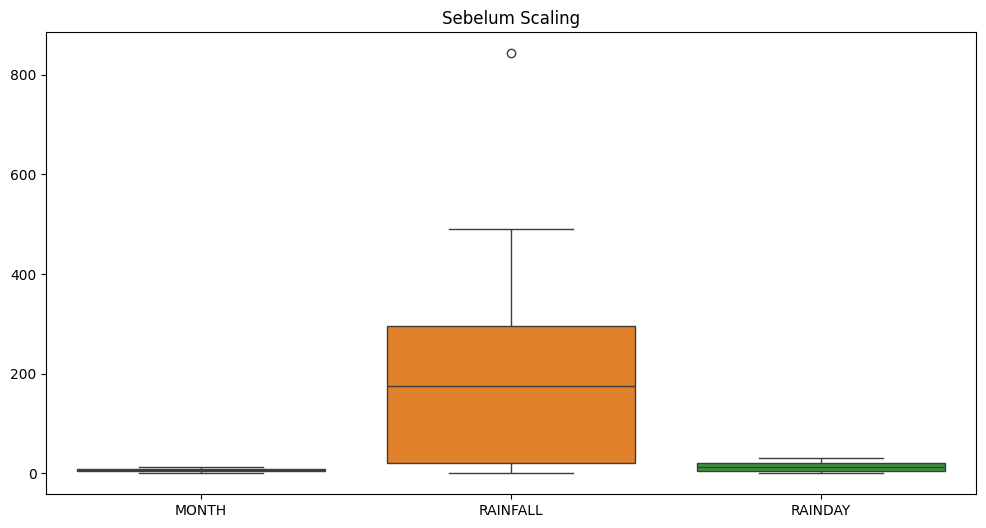

In [29]:
# sebelum scaling
plt.figure(figsize=(12,6))
sns.boxplot(data=pd.DataFrame(x, columns=df.columns[:-1]))
plt.title("Sebelum Scaling")
plt.show()

In [30]:
scaler = RobustScaler()
x_scalled = scaler.fit_transform(x)

In [31]:
x_scalled

array([[-1.00000000e+00,  6.25566636e-01,  5.00000000e-01],
       [-8.18181818e-01,  4.40616500e-01,  3.12500000e-01],
       [-6.36363636e-01,  4.87760653e-01,  3.12500000e-01],
       [-4.54545455e-01, -1.99456029e-02, -1.25000000e-01],
       [-2.72727273e-01,  8.88485947e-02, -1.87500000e-01],
       [-9.09090909e-02, -5.31278332e-01, -6.87500000e-01],
       [ 9.09090909e-02, -4.18857661e-01, -5.62500000e-01],
       [ 2.72727273e-01, -5.53037171e-01, -6.87500000e-01],
       [ 4.54545455e-01, -6.00181324e-01, -7.50000000e-01],
       [ 6.36363636e-01, -2.52039891e-01, -5.00000000e-01],
       [ 8.18181818e-01,  1.43245694e-01, -1.87500000e-01],
       [ 1.00000000e+00,  3.49954669e-01,  1.87500000e-01],
       [-1.00000000e+00,  7.19854941e-01,  3.12500000e-01],
       [-8.18181818e-01,  6.98096102e-01,  4.37500000e-01],
       [-6.36363636e-01,  7.37987307e-01,  3.12500000e-01],
       [-4.54545455e-01,  6.70897552e-02, -1.87500000e-01],
       [-2.72727273e-01,  7.45240254e-01

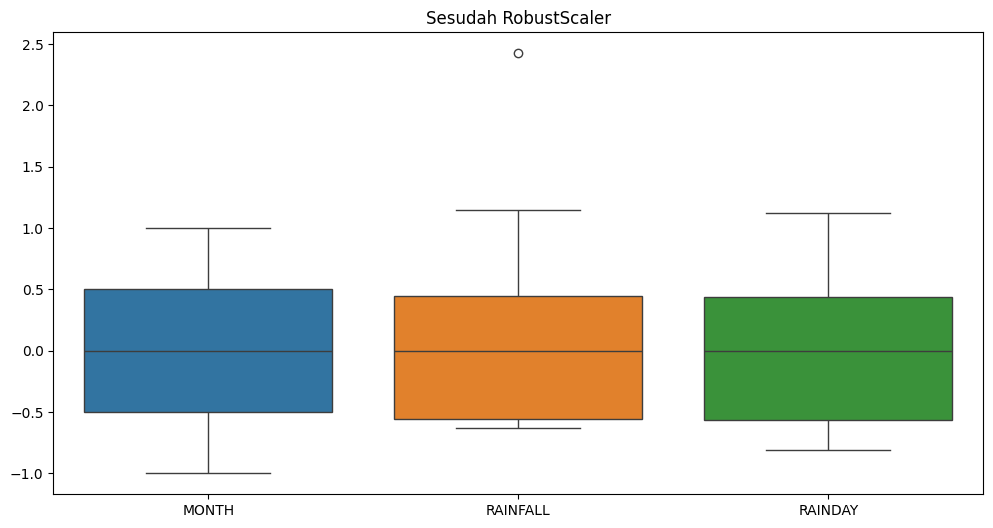

In [32]:
# sesudah scaling
plt.figure(figsize=(12,6))
sns.boxplot(data=pd.DataFrame(x_scalled, columns=df.columns[:-1]))
plt.title("Sesudah RobustScaler")
plt.show()

In [33]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [34]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [35]:
# Split data menjadi data latih dan data uji
x_train, x_test, y_train, y_test = train_test_split(
    x_scalled, y, test_size=0.2, random_state=0, stratify=y
)

In [36]:
# Inisialisasi model Random Forest dengan parameter tertentu
rf_model = RandomForestClassifier(
    n_estimators=50,  # Jumlah pohon
    criterion='entropy',  # Kriteria split
    max_depth=3,  # Kedalaman maksimum pohonS
    min_samples_split=4,  # Jumlah minimum sampel untuk memisahkan node
    min_samples_leaf=2,  # Jumlah minimum sampel di leaf node
    random_state=0  # Seed untuk reproduktibilitas
)

In [37]:
# Latih model
rf_model.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=3, min_samples_leaf=2,
                       min_samples_split=4, n_estimators=50, random_state=0)

In [38]:
# Prediksi pada data uji
y_pred = rf_model.predict(x_test)

In [39]:
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest: {accuracy}")
print(f"Laporan Klasifikasi:\n{classification_report(y_test, y_pred)}")

Akurasi Model Random Forest: 0.75
Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.71      0.83      0.77         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12



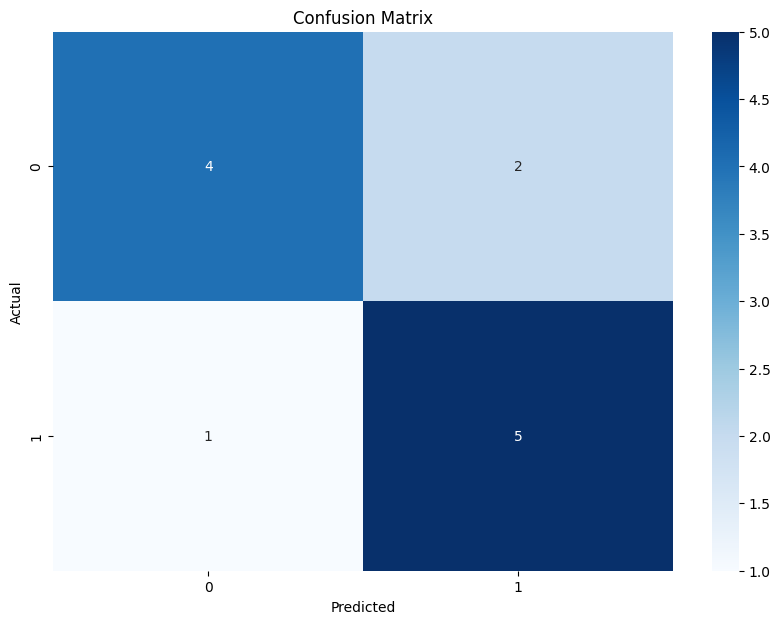

In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

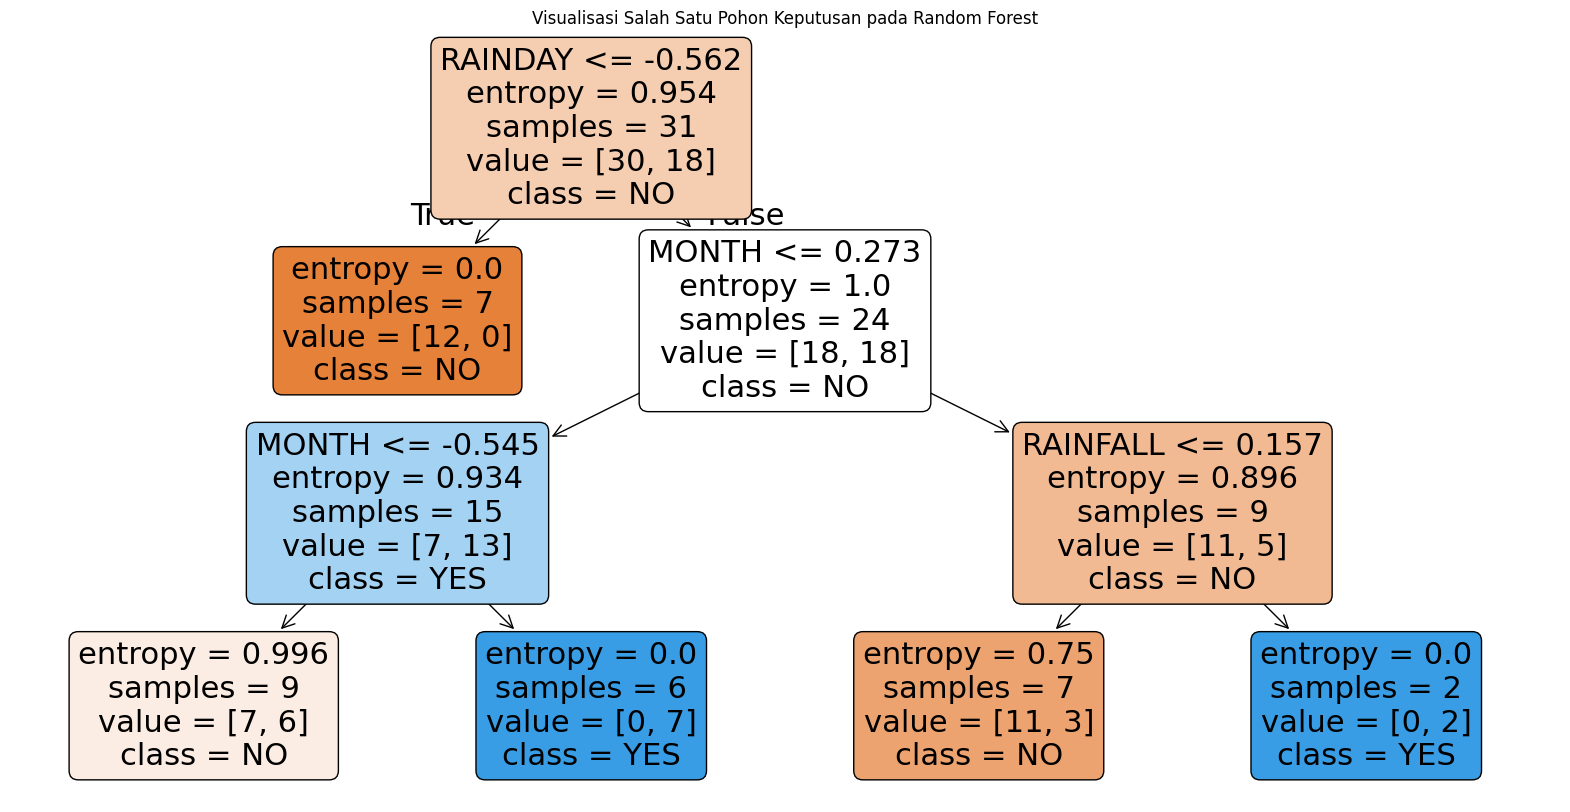

In [41]:
plt.figure(figsize=(20,10))
plot_tree(
    rf_model.estimators_[0],
    filled=True,
    feature_names=df.drop(columns=["FLOODS"]).columns,
    class_names=encoder.classes_,
    rounded=True
)
plt.title("Visualisasi Salah Satu Pohon Keputusan pada Random Forest")
plt.show()


    Feature  Importance
1  RAINFALL    0.407016
2   RAINDAY    0.384187
0     MONTH    0.208797


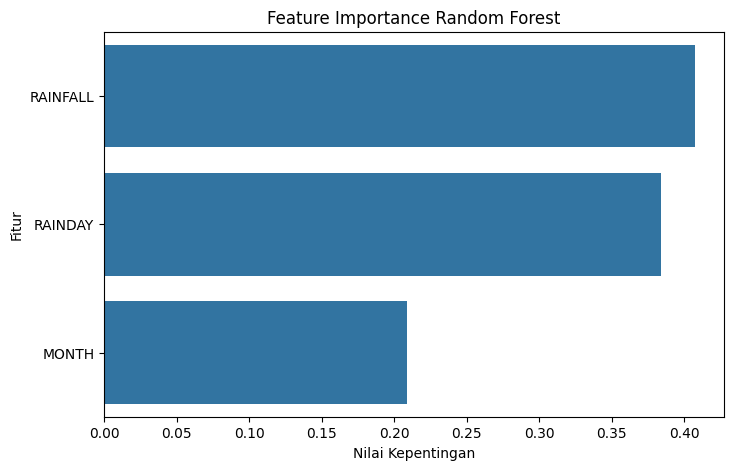

In [42]:
# Analisis Feature Importance
importances = rf_model.feature_importances_
feature_names = df.drop(columns=["FLOODS"]).columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# Visualisasi Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance Random Forest')
plt.xlabel('Nilai Kepentingan')
plt.ylabel('Fitur')
plt.show()


In [43]:
# Data baru (belum diproses)
new_data = pd.DataFrame({
    'MONTH': ['FEB'],
    'RAINFALL': [320],
    'RAINDAY': [19]
})

# Encoding MONTH
new_data['MONTH'] = new_data['MONTH'].map(month_map)
new_data_scaled = scaler.transform(new_data)
prediction = rf_model.predict(new_data_scaled)
prediction_label = encoder.inverse_transform(prediction)
print("Hasil Prediksi Banjir:", prediction_label[0])

Hasil Prediksi Banjir: YES


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(


In [44]:
import joblib

# Simpan model dan preprocessing
joblib.dump(rf_model, 'rf_banjir_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(encoder, 'label_encoder.joblib')
joblib.dump(month_map, 'month_mapping.joblib')

print("Model dan preprocessing berhasil disimpan.")


Model dan preprocessing berhasil disimpan.
